# notebook 01 - data loading & preparation

**goal:** load the analysis-ready pr dataset from a2, filter to agentic-only prs,
compute additional review-effort dimensions, merge task types, and persist the
clustering-ready dataset.

### review-effort dimensions (5 total)

| # | dimension | source | domain meaning |
|---|-----------|--------|---------------|
| 1 | `time_to_merge_hours` | a1/a2 | **duration** - how long the pr was under review before merging |
| 2 | `n_formal_reviews` | a1/a2 | **iterations** - how many formal review rounds were submitted |
| 3 | `n_review_comments` | a1/a2 | **depth** - how many inline review comments were made |
| 4 | `n_unique_reviewers` | derived | **breadth** - how many distinct humans participated in review |
| 5 | `churn_per_review_cycle` | derived | **burden** - code volume each review round had to cover |

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from src.config.settings import DATA_DIR, FIG_DIR, AGENT_ORDER, EFFORT_DIMENSIONS
from src.utils.helper import (
    load_base_parquet,
    load_task_types,
    load_pr_reviews,
    filter_agentic,
    compute_effort_dimensions,
    merge_task_types,
)

FIG_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. load base dataset

In [2]:
df = load_base_parquet()
print(f"total prs: {len(df):,}")
print(f"columns: {list(df.columns)}")
df.head(5)

total prs: 27,640
columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url', 'is_agentic', 'n_formal_reviews', 'has_review_data', 'n_review_comments', 'time_to_merge_hours', 'total_additions', 'total_deletions', 'total_files_changed', 'total_churn']


,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,is_agentic,n_formal_reviews,has_review_data,n_review_comments,time_to_merge_hours,total_additions,total_deletions,total_files_changed,total_churn
0,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26 04:56:55+00:00,2025-07-26T22:12:24Z,2025-07-26 22:12:24+00:00,1025472321.00,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,True,0,False,0,17.26,38.00,38.00,11.00,76.00
1,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26 13:31:19+00:00,2025-07-26T13:37:22Z,2025-07-26 13:37:22+00:00,988488798.00,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,True,2,True,2,0.10,298.00,109.00,5.00,407.00
2,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26 14:07:22+00:00,2025-07-26T14:45:30Z,2025-07-26 14:45:30+00:00,999285986.00,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,True,1,True,2,0.64,288.00,12.00,15.00,300.00
3,3214555104,16658,Add function signature breaking change detector,<details><summary>&#x1F6E0 DevTools &#x1F6E0</...,Claude_Code,17039389,harupy,closed,2025-07-09 05:35:26+00:00,2025-07-11T05:13:35Z,2025-07-11 05:13:35+00:00,136202695.00,https://api.github.com/repos/mlflow/mlflow,https://github.com/mlflow/mlflow/pull/16658,True,8,True,7,47.64,620.00,0.00,3.00,620.00
4,3214724259,5489,feat: add comprehensive test coverage for form...,## Summary\n\nThis PR enhances the forms plugi...,Claude_Code,82053242,wtfsayo,closed,2025-07-09 06:43:46+00:00,2025-07-09T06:44:02Z,2025-07-09 06:44:01+00:00,826170402.00,https://api.github.com/repos/elizaOS/eliza,https://github.com/elizaOS/eliza/pull/5489,True,1,True,0,0.00,1013.00,340.00,6.00,1353.00


agentic vs human split:

In [3]:
print(df["is_agentic"].value_counts().to_string())

is_agentic
True     22559
False     5081


## 2. filter to agentic-only prs

human prs lack review data (`n_formal_reviews`, `n_review_comments` are all 0
and commit details are nan). including them would introduce the `fillna(0)` bias
identified in a1's bonus analysis. we restrict to agentic prs where all three
original effort metrics are meaningfully populated.

In [4]:
df_agent = filter_agentic(df)
print(f"agentic prs: {len(df_agent):,}")

agentic prs: 22,559


In [5]:
print(f"per-agent breakdown:")
print(df_agent["agent"].value_counts().reindex(AGENT_ORDER).to_string())

per-agent breakdown:
agent
OpenAI_Codex    17424
Devin            2240
Copilot          1793
Cursor            887
Claude_Code       215


## 3. compute additional effort dimensions

we add two derived dimensions:
- `n_unique_reviewers`: distinct human reviewers per pr (from pr_reviews)
- `churn_per_review_cycle`: total lines changed per formal review round

In [6]:
rev_df = load_pr_reviews()
print(f"pr_reviews table: {len(rev_df):,} rows")
print(f"review states: {rev_df['state'].value_counts().to_dict()}")

/home/aang/miniconda3/envs/dataqueens/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pr_reviews table: 28,875 rows
review states: {'COMMENTED': 20431, 'APPROVED': 6499, 'CHANGES_REQUESTED': 1604, 'DISMISSED': 341}


descriptive statistics for effort dimensions:

In [7]:
df_agent = compute_effort_dimensions(df_agent, rev_df=rev_df)
df_agent[EFFORT_DIMENSIONS].describe().T

,count,mean,std,min,25%,50%,75%,max
time_to_merge_hours,22559.00,12.84,66.88,0.00,0.00,0.04,0.73,1797.70
n_formal_reviews,22559.00,0.71,2.36,0.00,0.00,0.00,0.00,30.00
n_review_comments,22559.00,0.55,2.84,0.00,0.00,0.00,0.00,63.00
n_unique_reviewers,22559.00,0.26,0.64,0.00,0.00,0.00,0.00,6.00
churn_per_review_cycle,22559.00,194.16,393.55,0.00,17.00,60.00,181.00,3123.00


zero-value prevalence (potential sparsity issue):

In [8]:
for col in EFFORT_DIMENSIONS:
    n_zero = (df_agent[col] == 0).sum()
    pct = 100 * n_zero / len(df_agent)
    print(f"  {col:30s}  zeros={n_zero:>6,}  ({pct:5.1f}%)")

  time_to_merge_hours             zeros=     0  (  0.0%)
  n_formal_reviews                zeros=17,434  ( 77.3%)
  n_review_comments               zeros=20,170  ( 89.4%)
  n_unique_reviewers              zeros=18,661  ( 82.7%)
  churn_per_review_cycle          zeros=    27  (  0.1%)


raw effort dimension distributions (log y-axis)

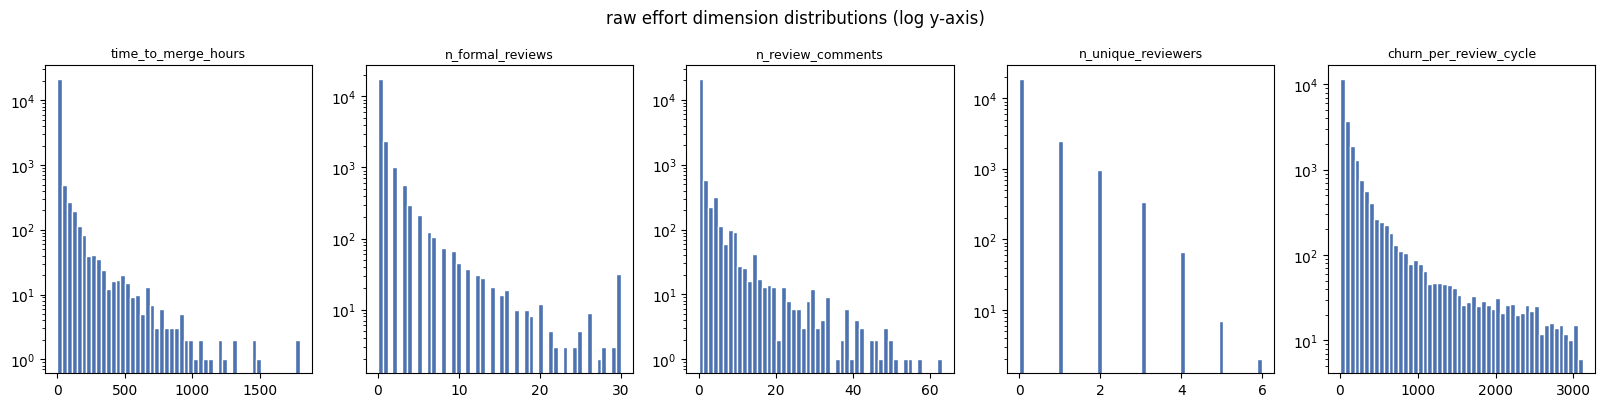

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, EFFORT_DIMENSIONS):
    ax.hist(df_agent[col], bins=50, edgecolor="white", color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.set_yscale("log")
fig.suptitle("raw effort dimension distributions (log y-axis)", y=1.02)
fig.savefig(FIG_DIR / "01_effort_dims_raw.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. merge task types

the `pr_task_type` table provides llm-classified task categories (feat, fix, docs, etc.)
for each pr. these will serve as external characteristics for cluster profiling.

In [10]:
task_df = load_task_types()
print(f"task type table: {len(task_df):,} rows")
print(f"task types: {task_df['type'].value_counts().to_dict()}")

task type table: 33,596 rows
task types: {'feat': 14450, 'fix': 8106, 'docs': 3887, 'test': 2356, 'refactor': 2288, 'chore': 896, 'build': 627, 'ci': 411, 'perf': 340, 'style': 188, 'other': 31, 'revert': 16}


after merge

In [11]:
df_agent = merge_task_types(df_agent, task_df)
print(f"after merge: {len(df_agent):,} rows")

after merge: 22,559 rows


task type coverage (non-null):

In [12]:
print(f"{df_agent['task_type'].notna().sum():,} / {len(df_agent):,}")

22,559 / 22,559


task type distribution:

In [13]:
print(df_agent["task_type"].value_counts().to_string())

task_type
feat        9564
fix         5047
docs        3152
test        1719
refactor    1471
chore        542
build        424
ci           316
perf         178
style        131
revert        12
other          3


## 5. verify pr body (text source for part 2)

part 2 requires pr descriptions (`body` column) for text classification.
check coverage and basic stats.

In [14]:
has_body = df_agent["body"].notna() & (df_agent["body"].str.strip() != "")
print(f"prs with non-empty body: {has_body.sum():,} / {len(df_agent):,} ({100*has_body.mean():.1f}%)")


prs with non-empty body: 22,411 / 22,559 (99.3%)


body length stats (characters):

In [15]:
df_agent.loc[has_body, "body"].str.len().describe()

count   22411.00
mean      670.57
std      1073.89
min         1.00
25%       261.00
50%       349.00
75%       540.50
max     52264.00
Name: body, dtype: float64

## 6. save clustering-ready dataset

In [16]:
out_path = DATA_DIR / "clustering_ready_prs.parquet"
df_agent.to_parquet(out_path, index=False)
print(f"saved {len(df_agent):,} rows x {df_agent.shape[1]} cols to {out_path.name}")
print(f"\nfinal columns: {list(df_agent.columns)}")

saved 22,559 rows x 26 cols to clustering_ready_prs.parquet

final columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url', 'is_agentic', 'n_formal_reviews', 'has_review_data', 'n_review_comments', 'time_to_merge_hours', 'total_additions', 'total_deletions', 'total_files_changed', 'total_churn', 'n_unique_reviewers', 'churn_per_review_cycle', 'task_type']
